# Homework #6

## Performance measures

This colaboratory also contains **Homework #6** of the Machine Learning course, which is due **December 7, midnight (23:59 EET time)**. To complete the homework, extract **(File -> Download .ipynb)** and submit to the course webpage.

## Submission's rules:

1.  Please, submit only .ipynb that you extract from the Colaboratory.
2.  Run your homework exercises before submitting (output should be present, preferably restart the kernel and press run all the cells).
3.  Do not change the description of tasks in red (even if there is a typo|mistake|etc).
4.  Please, make sure to avoid unnecessary long printouts.
5.  Each task should be solved right under the question of the task and not elsewhere.
6.  Solutions to both regular and bonus exercises should be submitted in one IPYNB file.

Please, steer clear of copying someone else's work. If you discuss assignments with anyone in the course, please, mention their names here:

Pooh


##List of Homework's exercises:

1.  [Ex1](#scrollTo=Va-cdXRPJ0qZ) - 3 points
2.  [Ex2](#scrollTo=lbbE3lltHbA_) - 3 points
3.  [Ex3](#scrollTo=NCdZudhH_WJc) - 4 points


In [137]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

# For plotting like a pro (actually, no)
!pip install -q plotnine
from plotnine import *


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Saskia\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


<font color=''> **Preparing the dataset for this homework.** We will be using the 'Credit-g' dataset from OpenML. This dataset classifies people described by a set of attributes as good or bad credit risks. To prepare the data for training, we will complete several prepropressing steps: impute the missing values (we will use [`sklearn Simple Imputer`](https://scikit-learn.org/1.5/modules/impute.html)), handle numerical and categorical features (`OneHotEncoder()` for categorical features and `StandardScaler()` for numerical) and split into training and test sets. **NB! We split data into train and validation before performing other preprocessing steps, this is important to avoid data leakage.**


In [138]:
from sklearn.datasets import fetch_openml

# Fetching 'Credit-g' dataset from OpenML
# https://www.openml.org/search?type=data&sort=runs&id=31
dataset = fetch_openml(name='credit-g')

In [139]:
dataset.data.describe(include = 'all') # explore the dataset

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
count,1000,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,1000,1000.000000,1000,1000,1000.000000,1000,1000.000000,1000,1000
unique,4,NaN,5,10,NaN,5,5,NaN,4,3,NaN,4,NaN,3,3,NaN,4,NaN,2,2
top,no checking,NaN,existing paid,radio/tv,NaN,<100,1<=X<4,NaN,male single,none,NaN,car,NaN,none,own,NaN,skilled,NaN,none,yes
freq,394,NaN,530,280,NaN,603,339,NaN,548,907,NaN,332,NaN,814,713,NaN,630,NaN,596,963
mean,NaN,20.903000,NaN,NaN,3271.258000,NaN,NaN,2.973000,NaN,NaN,2.845000,NaN,35.546000,NaN,NaN,1.407000,NaN,1.155000,NaN,NaN
std,NaN,12.058814,NaN,NaN,2822.736876,NaN,NaN,1.118715,NaN,NaN,1.103718,NaN,11.375469,NaN,NaN,0.577654,NaN,0.362086,NaN,NaN
min,NaN,4.000000,NaN,NaN,250.000000,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,19.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN
25%,NaN,12.000000,NaN,NaN,1365.500000,NaN,NaN,2.000000,NaN,NaN,2.000000,NaN,27.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN
50%,NaN,18.000000,NaN,NaN,2319.500000,NaN,NaN,3.000000,NaN,NaN,3.000000,NaN,33.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN
75%,NaN,24.000000,NaN,NaN,3972.250000,NaN,NaN,4.000000,NaN,NaN,4.000000,NaN,42.000000,NaN,NaN,2.000000,NaN,1.000000,NaN,NaN


In [140]:
# Convert to DataFrame for easier analysis
data = pd.DataFrame(data=dataset.data)
target = pd.DataFrame(dataset.target)

<font color='red'> Splitting the dataset into training and test sets. Note that we do it before all other transformations.


In [141]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.3, random_state=42)

In [142]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Here we use a more fancy way to transform our data using Pipeline class
# from sklearn https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html

# First let's identify which variables are numeric and categorical
numeric_features = data.select_dtypes(include=['int64', 'float64']).columns
categorical_features = data.select_dtypes(include=['object', 'category']).columns

# Defining a sequence of transformations for numeric variables
# We first impute missing values using median and then standardize
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Then define a sequence of transformations for categorical variables...
# Imputing missing values using the most frequent value and then convert into
# OneHotEncoded format
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Putting transformations together for both types of variables
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

<font color='red'> Here we first configure and apply preprocessing transformations first on the train subset and only then apply these transformations to test.


In [143]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"Shape of X_train_transformed: {X_train_transformed.shape}")
print(f"Shape of X_test_transformed: {X_test_transformed.shape}")

Shape of X_train_transformed: (700, 61)
Shape of X_test_transformed: (300, 61)


In [144]:
import matplotlib.pyplot as plt

# We will re-use this code in the future
def plot_class_distribution(y, title="Class Distribution"):

    class_counts = y.value_counts()

    class_counts.plot(kind='bar', color=['skyblue', 'orange'])
    plt.title(title, fontsize=14)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.xticks(rotation=0, fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()

<font color='red'> Let's take a look at the class distribution of this dataset.


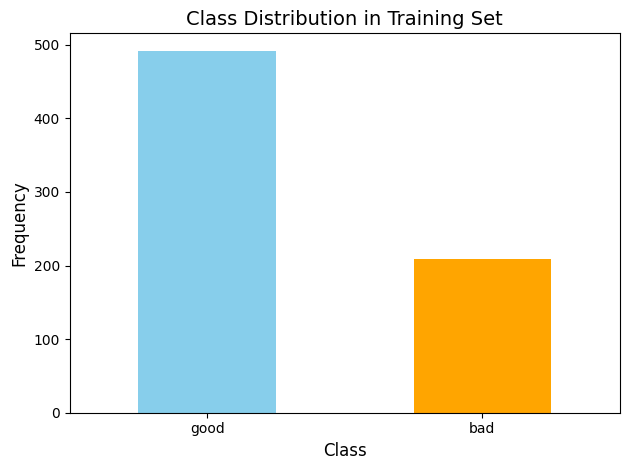

In [145]:
plot_class_distribution(y_train['class'], title="Class Distribution in Training Set")

<font color=''> This is a classical example of the unbalanced dataset i.e. one of the classes is twice or more prevalent than the other.</font>


---

## Homework exercise 1: compute macro and weighted averages for precision, recall and f1-score on an unbalanced dataset (3 points)

<font color=''> In this exercise we will calculate ordinary recall, precision and f1 measures and their macro- and weighted average versions. Learn more about macro and weighted averages here: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html </font>


In [146]:
# train a classifier
from sklearn.linear_model import LogisticRegression
logit = LogisticRegression(max_iter=10000, random_state=13)
logit.fit(X_train_transformed, y_train['class'])

# predicting on test
predictions_logit = logit.predict(X_test_transformed)

In [147]:
print(predictions_logit[:10])

['good' 'bad' 'bad' 'good' 'good' 'good' 'good' 'good' 'good' 'good']


<font color=''> **(Homework exercise 1- a)** Fill in the gaps to complete a function that calculates `tp`, `fn`, `fp`, `tn` depending on which class is considered to be `positive`. **(1 point)**</font>


In [148]:
import math

def compute_confusion_stats(classes, predictions, positive_class, negative_class):
  #### YOUR CODE STARTS ####

  pred_pos = classes[predictions == positive_class]
  pred_neg = classes[predictions == negative_class]

  tp = np.sum(pred_pos == positive_class)
  fn = np.sum(pred_neg == positive_class)
  fp = np.sum(pred_pos == negative_class)
  tn = np.sum(pred_neg == negative_class)
  #### YOUR CODE ENDS ####

  return (tp, fn, fp, tn)

def compute_rec_prec_f1(tp, fn, fp, tn):
  recall = tp / (tp + fn)
  precision = tp / (tp + fp)
  f1 = 2 * recall * precision / (precision + recall)
  if math.isnan(f1):
    f1 = 0
  return (recall, precision, f1)

<font color=''> Compute `tp`, `fn`, `fp`, `tn` and `recall`, `precision` and `f1` measures using functions `compute_confusion_stats` and `compute_rec_prec_f1` above. `recall`, `precision` and `f1` should be computed for both classes, e.g. `recall_good` is a recall when the `good` class is considered to be positive, `recall_bad` is a recall when the `bad` class is regarded as positive.</font>


In [149]:
# The 'good' class is considered positive
#### YOUR CODE STARTS ####
tp_good, fn_good, fp_good, tn_good = compute_confusion_stats(
	y_test['class'].values,
	predictions_logit,
	positive_class='good',
	negative_class='bad'
)

recall_good, precision_good, f1_good = compute_rec_prec_f1(
	tp_good,
	fn_good,
	fp_good,
	tn_good
)
#### YOUR CODE ENDS ####

print(f'Recall for the first class = {round(recall_good, 2)}')
print(f'Precision for the first class = {round(precision_good, 2)}')
print(f'F1 score for the first class = {round(f1_good, 2)}')

Recall for the first class = 0.9
Precision for the first class = 0.8
F1 score for the first class = 0.85


In [150]:
# The 'bad' class is considered positive
#### YOUR CODE STARTS ####
tp_bad, fn_bad, fp_bad, tn_bad = compute_confusion_stats(
	y_test['class'].values,
	predictions_logit,
	positive_class='bad',
	negative_class='good'
)
recall_bad, precision_bad, f1_bad = compute_rec_prec_f1(
	tp_bad,
	fn_bad,
	fp_bad,
	tn_bad
)
#### YOUR CODE ENDS ####

print(f'Recall for the second class = {round(recall_bad, 2)}')
print(f'Precision for the second class = {round(precision_bad, 2)}')
print(f'F1 score for the second class = {round(f1_bad, 2)}')

Recall for the second class = 0.48
Precision for the second class = 0.68
F1 score for the second class = 0.56


<font color=''> **(Homework exercise 1- b)** Without using any external libraries, calculate macro and weighted averages for all metrics. Run the `classification_report` function from `sklearn`, make sure that the outputs match. **(1 point)**</font>


In [151]:
#### YOUR CODE STARTS ####
# Calculate macro averages

macro_recall = (recall_good + recall_bad) / 2
macro_precision = (precision_good + precision_bad) / 2
macro_f1 = (f1_good + f1_bad) / 2

#### YOUR CODE ENDS ####

In [152]:
#### YOUR CODE STARTS ####
# Calculate class weights based on the number of instances in each class
total_instances = len(y_test)
weight_good = np.sum(y_test['class'] == 'good') / total_instances
weight_bad = np.sum(y_test['class'] == 'bad') / total_instances

# Calculate weighted averages
weighted_recall = (recall_good * weight_good) + (recall_bad * weight_bad)
weighted_precision = (precision_good * weight_good) + (precision_bad * weight_bad)
weighted_f1 = (f1_good * weight_good) + (f1_bad * weight_bad)

#### YOUR CODE ENDS ####

<font color=''> Compare all your results with the output of `classification_report` function. Make sure they are the same. </font>


In [153]:
from sklearn.metrics import classification_report

#### YOUR CODE STARTS ####
report = classification_report(
	y_test['class'],
	predictions_logit,
	target_names=['good', 'bad'],
	output_dict=True
)
#### YOUR CODE ENDS ####


In [154]:
print("Macro metrics:")
print(f'\tRecall = {round(macro_recall, 2)}')
print(f'\tPrecision = {round(macro_precision, 2)}')
print(f'\tF1 score = {round(macro_f1, 2)}')

print("")

print("Weighted metrics:")
print(f'\tRecall = {round(weighted_recall, 2)}')
print(f'\tPrecision = {round(weighted_precision, 2)}')
print(f'\tF1 score = {round(weighted_f1, 2)}')

print("")

print("Classification Report from sklearn:")

from pprint import pprint
pprint(report)

Macro metrics:
	Recall = 0.69
	Precision = 0.74
	F1 score = 0.71

Weighted metrics:
	Recall = 0.77
	Precision = 0.76
	F1 score = 0.76

Classification Report from sklearn:
{'accuracy': 0.7733333333333333,
 'bad': {'f1-score': 0.8468468468468469,
         'precision': 0.8,
         'recall': 0.8995215311004785,
         'support': 209.0},
 'good': {'f1-score': 0.5641025641025641,
          'precision': 0.676923076923077,
          'recall': 0.4835164835164835,
          'support': 91.0},
 'macro avg': {'f1-score': 0.7054747054747055,
               'precision': 0.7384615384615385,
               'recall': 0.691519007308481,
               'support': 300.0},
 'weighted avg': {'f1-score': 0.7610810810810811,
                  'precision': 0.7626666666666667,
                  'recall': 0.7733333333333333,
                  'support': 300.0}}


<font color=''> **(Homework exercise 1- c)** Use a different classifier on the same dataset. Calculate only weighted- and macro- average f1 score as we have just done for `LogisticRegression`. Compare the obtained results to figure out which classifier is better. **(1 point)**</font>


In [155]:
#### YOUR CODE STARTS ####
from sklearn.dummy import DummyClassifier

majority_class_model = DummyClassifier(strategy='most_frequent')

majority_class_model.fit(X_train_transformed, y_train['class'])

# predicting on test
predictions_majority_class = majority_class_model.predict(X_test_transformed)


# Calculate weighted averages

tp_mc_good, fn_mc_good, fp_mc_good, tn_mc_good = compute_confusion_stats(
	y_test['class'].values,
	predictions_majority_class,
	positive_class='good',
	negative_class='bad'
)

recall_mc_good, precision_mc_good, f1_mc_good = compute_rec_prec_f1(
	tp_mc_good,
	fn_mc_good,
	fp_mc_good,
	tn_mc_good
)

tp_mc_bad, fn_mc_bad, fp_mc_bad, tn_mc_bad = compute_confusion_stats(
	y_test['class'].values,
	predictions_majority_class,
	positive_class='bad',
	negative_class='good'
)

recall_mc_bad, precision_mc_bad, f1_mc_bad = compute_rec_prec_f1(
	tp_mc_bad,
	fn_mc_bad,
	fp_mc_bad,
	tn_mc_bad
)

total_mc_instances = len(y_test)
weight_mc_good = np.sum(y_test['class'] == 'good') / total_mc_instances
weight_mc_bad = np.sum(y_test['class'] == 'bad') / total_mc_instances

# Calculate weighted averages
#weighted_mc_recall = (recall_mc_good * weight_mc_good) + (recall_mc_bad * weight_mc_bad)
#weighted_mc_precision = (precision_mc_good * weight_mc_good) + (precision_mc_bad * weight_mc_bad)
weighted_mc_f1 = (f1_mc_good * weight_mc_good) + (f1_mc_bad * weight_mc_bad)


#macro_mc_recall = (recall_mc_good + recall_mc_bad) / 2
#macro_mc_precision = (precision_mc_good + precision_mc_bad) / 2
macro_mc_f1 = (f1_mc_good + f1_mc_bad) / 2

#weighted_avg_f1 = weighted_mc_f1


print(f'Weighted averaging for f1 = {np.round(weighted_mc_f1, 2)}')
print(f'Macro averaging for f1 = {np.round(macro_mc_f1, 2)}')
#### YOUR CODE ENDS ####

Weighted averaging for f1 = 0.57
Macro averaging for f1 = 0.41


In [156]:
#The DummyClassifier performs significantly worse than LogisticRegression in both weighted and macro F1, showing that LogisticRegression captures meaningful patterns beyond predicting the majority class.

---

## Homework exercise 2: compare multiple classification methods using precision-recall curve (3 points)

<font color=''> In the lecture and practice session we have discussed how receiver operating characteristic (ROC) and the corresponding area under this curve (AUC) can be used to assess classifier's performance. Although, being super popular and in majority cases adequate, ROC AUC can be overly optimistic when used on classifiers trained on severely imbalanced data. Another metric, namely - Precision-Recall Curve (PRC) is considered more appropriate for such data. In this exercise, we will learn to build PRC and use it to evaluate already familiar classifiers. Check out [this page](https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-imbalanced-classification/) if you want to know more about PRCs. </font>


<font color=''> **(Homework exercise 2- a)** Train three models (logistic regression, KNN and random forest) on the dataset from EX1. Calculate accuracy for each model on validation set using function `score` and model objects. Treat `good` as negative class and `bad` as positive. Separately, compute and print out the accuracy of the majority class classifier (_hint_: you can use `DummyClassifier` from `sklearn` to imitate majority class classifier). **(1 point)**</font>


In [157]:
#y_train_bin = y_train['class'].map({'good': 0, 'bad': 1})
#y_test_bin  = y_test['class'].map({'good': 0, 'bad': 1})

In [158]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

np.random.seed(1111) # random seed for consistency

#### YOUR CODE STARTS ####
# define all three classifiers using default parameters
logistic_model = LogisticRegression(random_state=1111)
knn_model = KNeighborsClassifier() #random_state=1111
random_forest_model = RandomForestClassifier(random_state=1111)

# train classifiers
logistic_model.fit(X_train_transformed, y_train['class'])
knn_model.fit(X_train_transformed, y_train['class'])
random_forest_model.fit(X_train_transformed, y_train['class'])

# Dummy

majority_model = DummyClassifier(strategy='most_frequent', random_state=1111)
majority_model.fit(X_train_transformed, y_train['class'])

#### YOUR CODE ENDS ####

,strategy,'most_frequent'
,random_state,1111
,constant,None


<font color='red'> Get probability scores for the positive class on the test data from all four models (including the majority class classifier). </font>


In [159]:
#### YOUR CODE STARTS ####
logistic_model_acc = logistic_model.score(X_test_transformed, y_test['class'])
knn_model_acc = knn_model.score(X_test_transformed, y_test['class'])
random_forest_model_acc = random_forest_model.score(X_test_transformed, y_test['class'])

majority_model_acc = majority_model.score(X_test_transformed, y_test['class'])
#### YOUR CODE ENDS ####

In [160]:
print(f'Logistic Regression accuracy: {np.round(logistic_model_acc, 2)}')
print(f'KNN accuracy: {np.round(knn_model_acc, 2)}')
print(f'Random Forest accuracy: {np.round(random_forest_model_acc, 2)}')
print(f'Majority class accuracy: {np.round(majority_model_acc, 2)}')

Logistic Regression accuracy: 0.77
KNN accuracy: 0.74
Random Forest accuracy: 0.74
Majority class accuracy: 0.7


<font color='red'> Take a look at the expanded `y_test` data.frame, where we added predicted probabilities by each model. </font>


<font color=''> **(Homework exercise 2- b)** Here we implement and visualise PR curves for the classifiers built in the previous subtask (2-a). **(1 point)**</font>


<font color=''> Transform the function `generate_coordinates` from the practice session into a new function `generate_PR_coordinates` such that the latter instead of FPRs and TPRs computes Precision and Recall for each possible threshold. Note that unlike practice session we have `good` and `bad` as labels instead of 0 and 1. Make use of `positive_label` variable to compute `tp`, `fn` and `fp` metrics. </font>


In [161]:
def generate_PR_coordinates(scores, classes, positive_label="bad"):

  # obtain thresholds using sorted unique score values
  thresholds = np.sort(scores.unique())[::-1]

  # initialise
  precisions = []
  recalls = []

  for threshold in thresholds:

    ##### YOUR CODE STARTS #####
    # make use of positive_label


    # predicted labels from threshold
    predictions = scores >= threshold

    # split true classes based on predictions
    pred_positive = classes[predictions]
    pred_negative = classes[~predictions]

    # confusion matrix components
    tp = np.sum(pred_positive == positive_label)
    fn = np.sum(pred_negative == positive_label)
    fp = np.sum(pred_positive != positive_label)
    tn = np.sum(pred_negative != positive_label)

    # metrics
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    ##### YOUR CODE ENDS #####

    recalls.append(recall)
    precisions.append(precision)

  pr_coordinates = pd.DataFrame({'PRECISION': np.round(precisions, 3),
                                 'RECALL': np.round(recalls, 3)},
                                index=thresholds)

  return pr_coordinates

<font color='red'> Create PRC coordinates for each model using `generate_PR_coordinates`. </font>


In [162]:
logistic_model.classes_

array(['bad', 'good'], dtype=object)

In [163]:
#### YOUR CODE STARTS ####

log_proba = logistic_model.predict_proba(X_test_transformed)[:, 0]
log_proba_series = pd.Series(log_proba, index=y_test.index)

prc_logistic_model = generate_PR_coordinates(
	log_proba_series,
	y_test['class'],
)


knn_proba = knn_model.predict_proba(X_test_transformed)[:, 0]
knn_proba_series = pd.Series(knn_proba, index=y_test.index)

prc_knn_model = generate_PR_coordinates(
	knn_proba_series,
	y_test['class'],
)


rf_proba = random_forest_model.predict_proba(X_test_transformed)[:, 0]
rf_proba_series = pd.Series(rf_proba, index=y_test.index)

prc_rf_model = generate_PR_coordinates(
	rf_proba_series,
	y_test['class'],
)

mc_proba = majority_model.predict_proba(X_test_transformed)[:, 0]
mc_proba_series = pd.Series(mc_proba, index=y_test.index)

prc_mc_model = generate_PR_coordinates(
	mc_proba_series,
	y_test['class'],
)

#### YOUR CODE ENDS ####

In [164]:
# Note that our PRCs will start from 1,0 not 0,0 in case of ROCs
top_row =  pd.DataFrame({'PRECISION':1, 'RECALL':0}, index=[1.0])

#### YOUR CODE STARTS ####
prc_logistic_model = pd.concat([top_row, prc_logistic_model])
prc_knn_model = pd.concat([top_row, prc_knn_model])
prc_rf_model = pd.concat([top_row, prc_rf_model])

prc_mc_model = pd.concat([top_row, prc_mc_model])
#### YOUR CODE ENDS ####

<font color='red'> Next, use function `plot_pr` which was provided to you to visualise PRCs for all four models. </font>


In [165]:
def plot_pr(coordinates_dict):
  """
  plot_pr function plots all models' PRCs on one plot
  """
  plotting_data = pd.DataFrame(columns=['PRECISION', 'RECALL', 'Method'])

  for id, name in enumerate(coordinates_dict.keys()):
    method_data = coordinates_dict[name]
    method_data['Method'] = name
    plotting_data = pd.concat([plotting_data, method_data])

  plotting_data['Method'] = pd.Categorical(plotting_data['Method'])

  roc_plot = (
        ggplot(data = plotting_data, # creates a canvas
        mapping = aes(x = 'RECALL', y = 'PRECISION', colour = 'Method')) + # specifies dimensions
        geom_path(size = 1.5) + # determines geometric primitive to be visualised (path/line in our case) and its thickness
        labs(title ='', x = 'RECALL', y = 'PRECISION') + # labels of the x and y axes
        theme_bw() + # colour schema
        theme(figure_size = (5, 5), # figure size
              axis_line = element_line(size = 0.5, colour = "black"),
              panel_grid_major = element_line(size = 0.05, colour = "black"),
              panel_grid_minor = element_line(size = 0.05, colour = "black"),
              axis_text = element_text(colour ='black')) # more formatting details
      )
  return roc_plot


<font color='red'> Visualise the resulting PR curves below. </font>


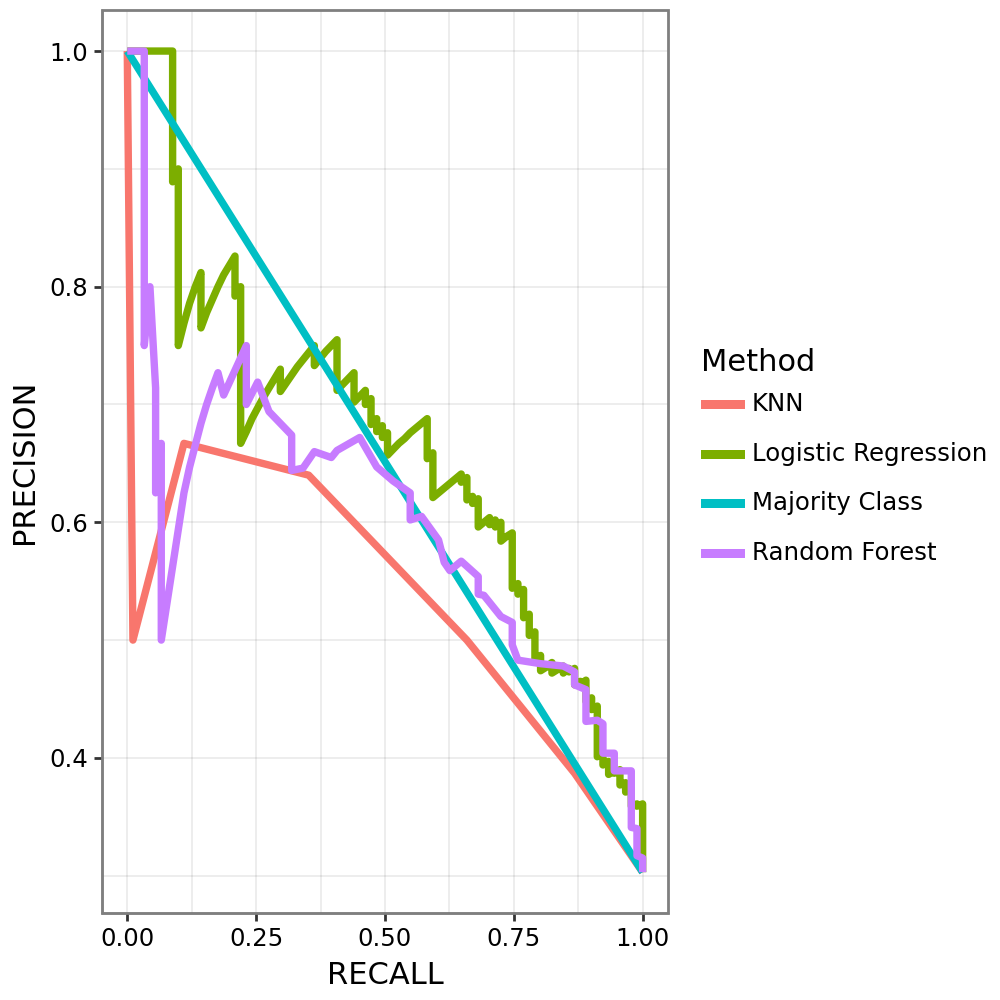

In [166]:
#### YOUR CODE STARTS ####
plot = plot_pr(
	{
	'Logistic Regression': prc_logistic_model,
	'KNN': prc_knn_model,
	'Random Forest': prc_rf_model,
	'Majority Class': prc_mc_model
  }
)

plot
#### YOUR CODE ENDS ####

<font color=''> **(Homework exercise 2- c)** Use sklearn functions `PrecisionRecallDisplay` and `precision_recall_curve` and matplotlib to verify that your curves from 2-b are correct. **(0.5 points)**</font>


In [167]:
y_true = y_test['class']

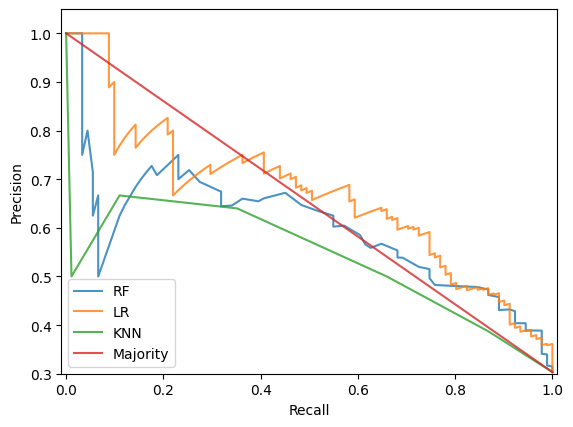

In [168]:
#Importing the required libraries
from sklearn.metrics._plot.precision_recall_curve import PrecisionRecallDisplay
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
ax = plt.gca()

#### YOUR CODE STARTS ####

(precision, recall, thresholds) = precision_recall_curve(y_true, rf_proba, pos_label='bad')
rf_disp = PrecisionRecallDisplay(
	precision=precision,
	recall=recall,
)

(precision, recall, thresholds) = precision_recall_curve(y_true, log_proba, pos_label='bad')
lr_disp = PrecisionRecallDisplay(
	precision=precision,
	recall=recall,
)

(precision, recall, thresholds) = precision_recall_curve(y_true, knn_proba, pos_label='bad')
knn_disp = PrecisionRecallDisplay(
	precision=precision,
	recall=recall,
)

(precision, recall, thresholds) = precision_recall_curve(y_true, mc_proba, pos_label='bad')
majority_disp = PrecisionRecallDisplay(
	precision=precision,
	recall=recall,
)

#### YOUR CODE ENDS ####

rf_disp.plot(ax=ax, alpha=0.8, drawstyle = 'default', label='RF')
lr_disp.plot(ax=ax, alpha=0.8, drawstyle = 'default', label='LR')
knn_disp.plot(ax=ax, alpha=0.8, drawstyle = 'default', label='KNN')
majority_disp.plot(ax=ax, alpha=0.8, drawstyle = 'default', label='Majority')

ax.set_ylim(0.3, 1.05)
plt.show()

<font color=''> **(Homework exercise 2- d)** Create two ensembles: VotingClassifier (with soft voting) and StackingClassifier using previously trained (reasonable) models. Visualise performances of the ensembles using PRCs. Add PRCs from the previous models on the same plot for the comparison. Analyse the resulting plot and provide the interpretation. **(0.5 points)**</font>


In [169]:
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier


#### YOUR CODE STARTS ####
# Voting
voting_clf = VotingClassifier(
	estimators=[
		('logistic', logistic_model),
		('knn', knn_model),
		('random_forest', random_forest_model)
	],
	voting='soft' # use 'hard' for majority voting
)

voting_clf.fit(X_train_transformed, y_train['class'])

# Stacking
stacking_clf = StackingClassifier(
	estimators=[
		('logistic', logistic_model),
		('knn', knn_model),
		('random_forest', random_forest_model)
	],
	final_estimator=LogisticRegression(),
	cv=5
)

stacking_clf.fit(X_train_transformed, y_train['class'])


#### YOUR CODE ENDS ####

,estimators,"[('logistic', ...), ('knn', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


<font color=''> Create PRC coordinates for each model using `generate_PR_coordinates`. </font>


In [170]:
#### YOUR CODE STARTS ####

voting_clf.fit(X_train_transformed, y_train['class'])
stacking_clf.fit(X_train_transformed, y_train['class'])

prc_voting = generate_PR_coordinates(
	pd.Series(
		voting_clf.predict_proba(X_test_transformed)[:, 0],
		index=y_test.index
	),
	y_test['class'],
)

prc_stacking = generate_PR_coordinates(
	pd.Series(
		stacking_clf.predict_proba(X_test_transformed)[:, 0],
		index=y_test.index
	),
	y_test['class'],
)

#### YOUR CODE ENDS ####

<font color=''> Visualise the resulting PR curves below. </font>


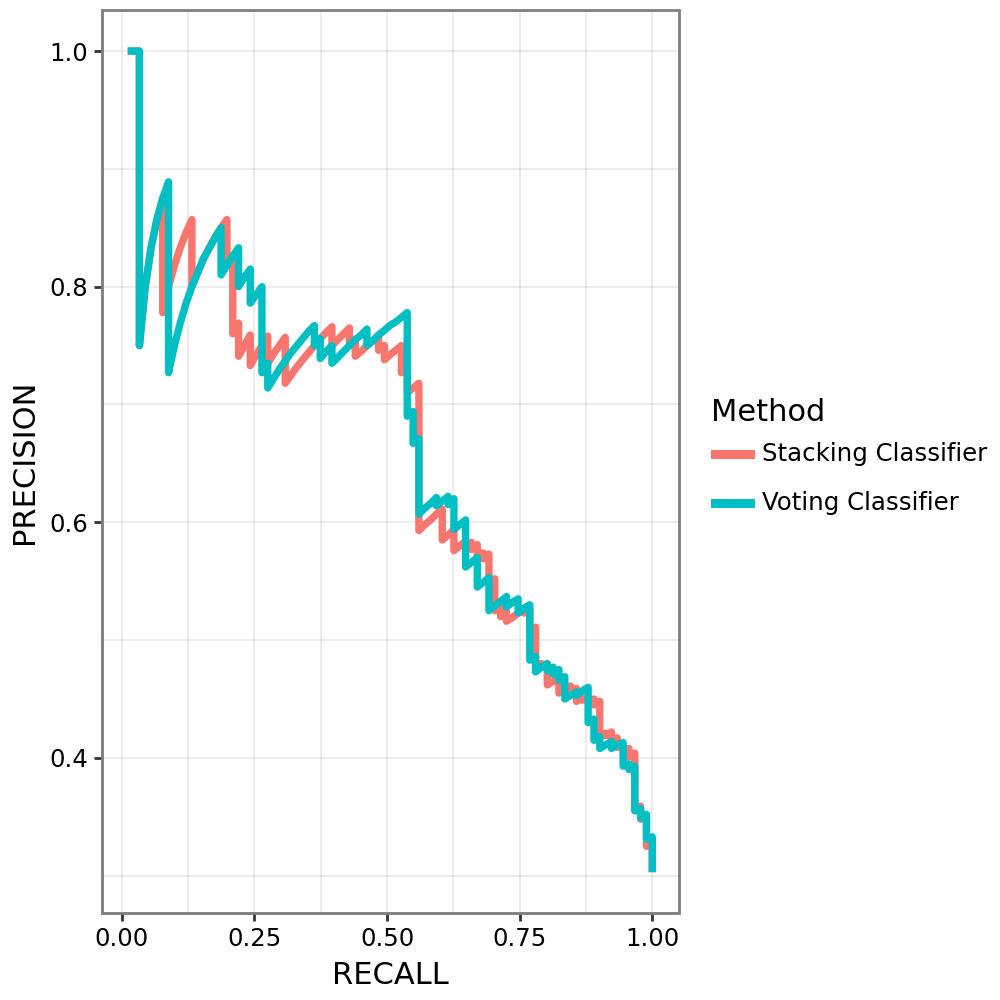

In [171]:
#### YOUR CODE STARTS ####


plot_pr({
	'Voting Classifier': prc_voting,
	'Stacking Classifier': prc_stacking
})

#### YOUR CODE ENDS ####

<font color=''> Analyse the above figure and explain why both stacking and voting models exhibit steep decline in the upper left corner. Your answer: </font>


The steep decline in the upper left corner occurs because ensembles (stacking and voting) are highly confident in only a few top predictions. Slightly lowering thresholds to include more positives quickly brings in many false positives, sharply decreasing precision.


## Homework exercise 3: improving classifier's performance with dataset balancing (4 points)


<font color=''> **(Homework exercise 3- a)** Explore the class distribution of the credit dataset. Train a classifier on the original dataset. Evaluate it on the test set using several performance metrics. Use sklearn for calculating metrics, no need to implement them yourself. **(1 point)**</font>


<font color=''> Plot the histogram of the class distribution below to remind ourselves how badly unbalanced the dataset is.</font>


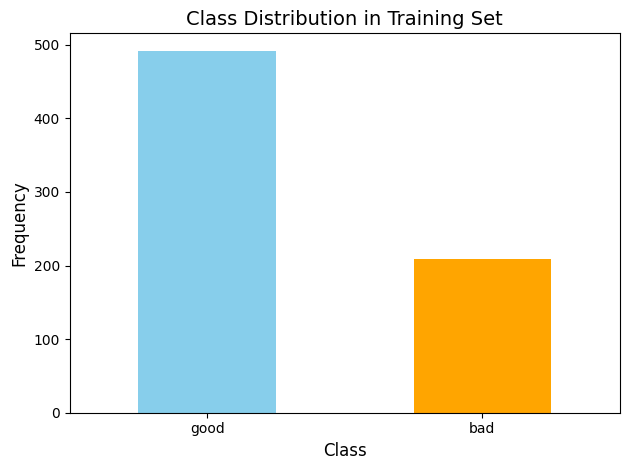

In [172]:
plot_class_distribution(y_train['class'], title="Class Distribution in Training Set")

<font color=''> Choose a classifier - **don't use DecisionTreeClassifier**, it only returns 0/1 for probabilities - train it on the training data and predict customer's credict risk (`bad` or `good`) on the test. Again, treat `good` as negative class and `bad` as positive. </font>


In [173]:
#### YOUR CODE STARTS ####
rfc = RandomForestClassifier(random_state=21)
rfc.fit(X_train_transformed, y_train['class'])
rfc_acc = rfc.score(X_test_transformed, y_test['class'])
print(f'Random Forest with accuracy: {np.round(rfc_acc, 2)}')
#### YOUR CODE ENDS ####

Random Forest with accuracy: 0.76


<font color=''> Next, write a function `compute_and_print_metrics` where include four different metrics that we have studied in the class + Matthews Correlation Coefficient (also known as Phi coefficient in statistics), here is the [link](https://en.wikipedia.org/wiki/Phi_coefficient). </font>


In [174]:
#from sklearn.metrics import roc_auc_score


#def compute_and_print_metrics(y_test, y_pred):
#  #### YOUR CODE STARTS ####
#  tp, fn, fp, tn = compute_confusion_stats(
#  	y_test['class'].values,
#  	y_pred,
#  	positive_class='bad',
#  	negative_class='good'
#  )

#  recall, precision, f1 = compute_rec_prec_f1(tp, fn, fp, tn)
#  accuracy = (tp + tn) / (tp + tn + fp + fn)


#  print(f'Accuracy: {np.round(accuracy, 2)}')
#  print(f'Recall: {np.round(recall, 2)}')
#  print(f'Precision: {np.round(precision, 2)}')
#  print(f'F1 score: {np.round(f1, 2)}')

#  #	Phi coefficient MCC
#  MCC = (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
#  print(f'Phi coefficient (MCC): {np.round(MCC, 2)}')

#  AUC = roc_auc_score(
#  	y_test['class'].map({'good': 0, 'bad': 1}),
#  	y_pred.map({'good': 0, 'bad': 1})
#  )
#  print(f'AUC: {np.round(AUC, 2)}')


#  #### YOUR CODE ENDS ####

In [175]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score

def compute_and_print_metrics(y_test, y_pred):
  #### YOUR CODE STARTS ####
	y_pred_bin = np.where(y_pred == 'bad', 1, 0)
	y_true = y_test['class'].map({'good': 0, 'bad': 1}).values

	accuracy = accuracy_score(y_true, y_pred_bin)
	precision = precision_score(y_true, y_pred_bin)
	recall = recall_score(y_true, y_pred_bin)
	f1 = f1_score(y_true, y_pred_bin)
	mcc = matthews_corrcoef(y_true, y_pred_bin)

	# If you have probabilities:
	#auc = roc_auc_score(y_true, y_pred_proba)

	print(f'Accuracy: {accuracy:.2f}')
	print(f'Precision: {precision:.2f}')
	print(f'Recall: {recall:.2f}')
	print(f'F1 score: {f1:.2f}')
	print(f'Phi coefficient (MCC): {mcc:.2f}')


  #### YOUR CODE ENDS ####

<font color=''> Use `compute_and_print_metrics` to evaluate the model of your choice. </font>


In [176]:
y_pred = rfc.predict(X_test_transformed)

compute_and_print_metrics(y_test, y_pred)

Accuracy: 0.76
Precision: 0.69
Recall: 0.36
F1 score: 0.47
Phi coefficient (MCC): 0.36


<font color=''> **(Homework exercise 3- b)** Create three balanced versions of the original dataset using:

-   <font color=''> Oversampling method </font>
-   <font color=''> Undersampling method </font>
-   <font color=''> Combination of Over- and Undersampling methods </font>

Select **only** over- and undersampling methods that we have discussed in the regularisation lecture part II. Retrain your chosen classifier on each of the versions and evaluate on the original test set. Store models trained on different versions of the dataset in different variables, they will be useful for the next task. **(1 point)** </font>


<font color='red'> Below use an **oversampling** approach. </font>


In [177]:
!pip install imbalanced-learn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Saskia\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [178]:
#### YOUR CODE STARTS ####
from imblearn.over_sampling import SMOTE

X_over, y_over = SMOTE().fit_resample(X_train_transformed, y_train['class'])
#### YOUR CODE ENDS ####

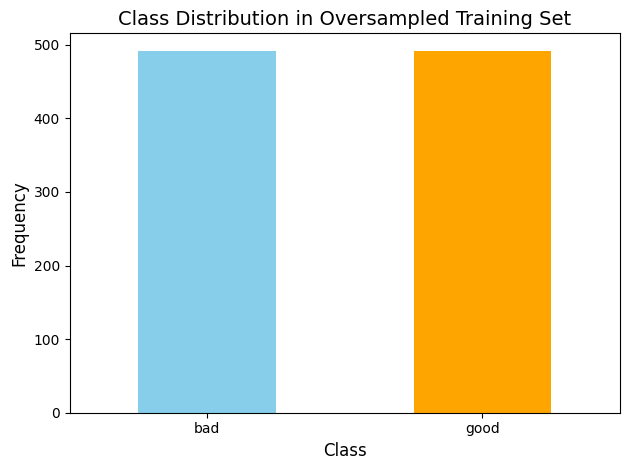

In [179]:
plot_class_distribution(y_over, title="Class Distribution in Oversampled Training Set")

<font color='red'> Re-train your classifier on **oversampled** version of the dataset and use `compute_and_print_metrics` to evaluate it. </font>


In [180]:
y_test

,class
521,bad
737,good
740,good
660,good
411,good
...,...
468,good
935,bad
428,good
7,good


In [181]:
#### YOUR CODE STARTS ####
rcf_SMOTE = RandomForestClassifier(random_state=21)
rcf_SMOTE.fit(X_over, y_over)

y_pred_SMOTE = rcf_SMOTE.predict(X_test_transformed)

compute_and_print_metrics(y_test, y_pred_SMOTE)
#### YOUR CODE ENDS ####

Accuracy: 0.74
Precision: 0.59
Recall: 0.43
F1 score: 0.50
Phi coefficient (MCC): 0.33


<font color='red'> Below use an **undersampling** approach. </font>


In [182]:
#### YOUR CODE STARTS ####
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=21)

X_under, y_under = rus.fit_resample(X_train_transformed, y_train['class'])


#from imblearn.under_sampling import ClusterCentroids
#cc = ClusterCentroids(random_state=21)

#X_under, y_under = cc.fit_resample(X_train_transformed, y_train['class'])
#### YOUR CODE ENDS ####

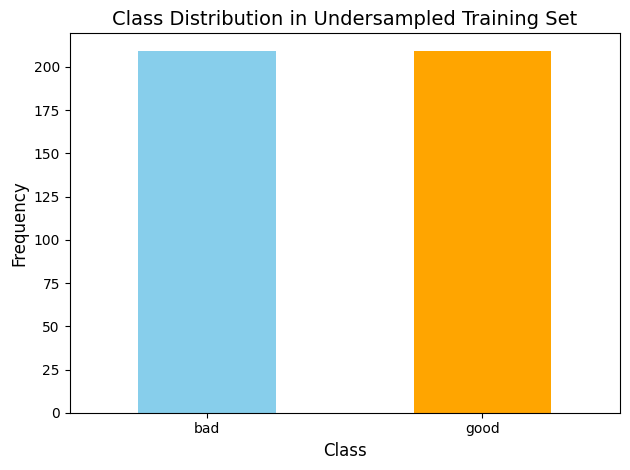

In [183]:
plot_class_distribution(y_under, title="Class Distribution in Undersampled Training Set")

<font color='red'> Re-train your classifier on **undersampled** version of the dataset and use `compute_and_print_metrics` to evaluate it. </font>


In [184]:
#### YOUR CODE STARTS ####
rcf_rus = RandomForestClassifier(random_state=21)
rcf_rus.fit(X_under, y_under)

y_pred_rus = rcf_rus.predict(X_test_transformed)

compute_and_print_metrics(y_test, y_pred_rus)
#### YOUR CODE ENDS ####

Accuracy: 0.71
Precision: 0.52
Recall: 0.68
F1 score: 0.59
Phi coefficient (MCC): 0.38


<font color='red'> Below use an approach that combines **over-** and **undersampling**. </font>


In [185]:
#### YOUR CODE STARTS ####
from imblearn.combine import SMOTEENN
smote_enn = SMOTEENN(random_state=21)

X_overunder, y_overunder = smote_enn.fit_resample(X_train_transformed, y_train['class'])
#### YOUR CODE ENDS ####

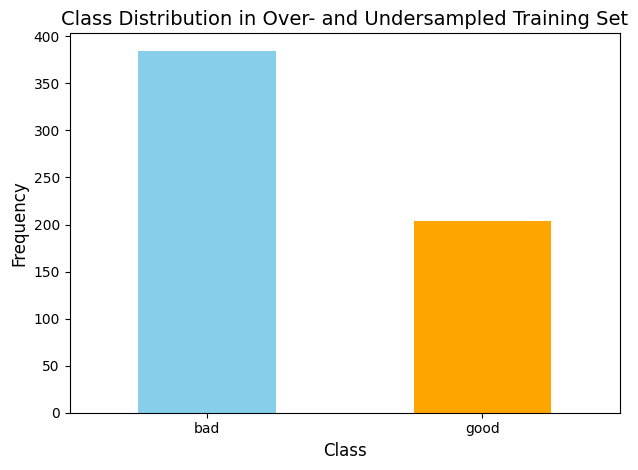

In [186]:
plot_class_distribution(y_overunder, title="Class Distribution in Over- and Undersampled Training Set")

<font color='red'> Re-train your classifier on **over + undersampled** version of the dataset and use `compute_and_print_metrics` to evaluate it. </font>


In [187]:
#### YOUR CODE STARTS ####
rcf_SMOTE_EEN = RandomForestClassifier(random_state=21)
rcf_SMOTE_EEN.fit(X_overunder, y_overunder)

y_pred_SMOTE_EEN = rcf_SMOTE_EEN.predict(X_test_transformed)

compute_and_print_metrics(y_test, y_pred_SMOTE_EEN)
#### YOUR CODE ENDS ####

Accuracy: 0.69
Precision: 0.50
Recall: 0.79
F1 score: 0.61
Phi coefficient (MCC): 0.41


<font color='red'> **(Homework exercise 3- c)** Visualise ROC and PR curves for all four classifiers you have trained. Generate two plots, one for ROC curves and one for PR curves. **(1 point)**</font>


<font color='red'> Below visualise corresponding **ROC** curves. </font>


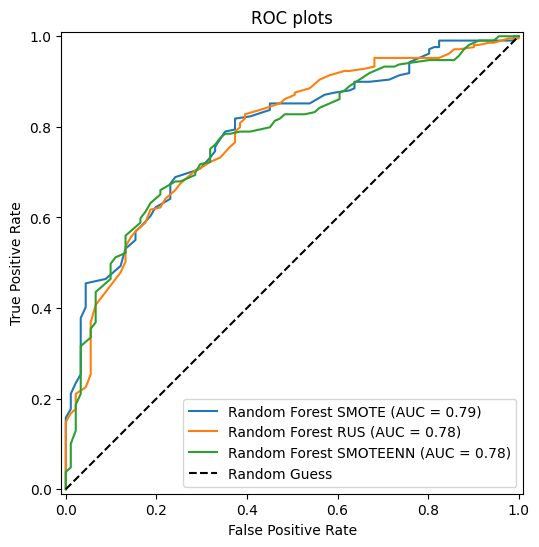

In [188]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

models = {
    'Random Forest SMOTE': rcf_SMOTE,
    'Random Forest RUS': rcf_rus,
    'Random Forest SMOTEENN': rcf_SMOTE_EEN
}

plt.figure(figsize=(8, 6))
ax = plt.gca()  # get current axes to plot all ROC curves on same plot

for name, model in models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test_transformed,
        y_test['class'],
        name=name,
        ax=ax  # important: draw all on the same axes
    )

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')  # optional diagonal
plt.title("ROC plots")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()


<font color='red'> Below visualise corresponding **PR** curves. </font>


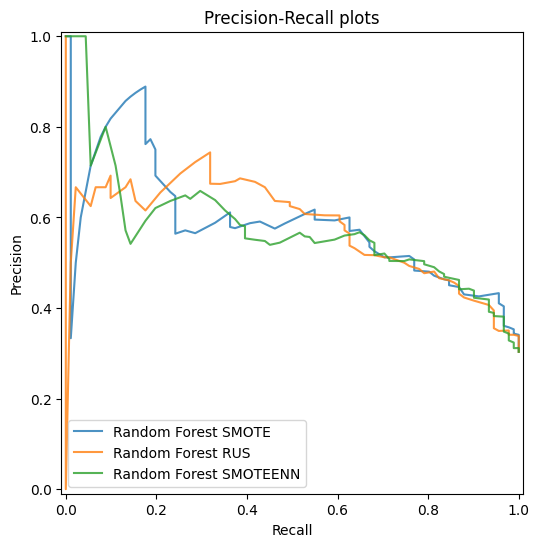

In [189]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

models = {
    'Random Forest SMOTE': rcf_SMOTE,
    'Random Forest RUS': rcf_rus,
    'Random Forest SMOTEENN': rcf_SMOTE_EEN
}

plt.figure(figsize=(8, 6))
ax = plt.gca()

for name, model in models.items():
    precision, recall, _ = precision_recall_curve(
        y_test['class'],
        model.predict_proba(X_test_transformed)[:, 0],
        pos_label='bad'
    )

    disp = PrecisionRecallDisplay(
       precision=precision,
         recall=recall,
    )
    disp.plot(ax=ax, alpha=0.8, drawstyle = 'default', label=f'{name}')


# Convert y_test to numeric once
#y_true_numeric = y_test['class'].map({'good': 0, 'bad': 1}).to_numpy()
## Baseline for random classifier
#baseline = y_true_numeric.mean()
#plt.hlines(y=baseline, xmin=0, xmax=1, colors='k', linestyles='--', label='Random Guess')

plt.title("Precision-Recall plots")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left')
plt.show()


<font color=''> **(Homework exercise 3- d)** Answer the following questions, make sure to sufficiently but not excessively justify your reasoning (consider `good` to be a negative class):

-   <font color=''> Which metric would you choose if you wanted to minimise the number of people you reject as characterised by `bad` credict risk (e.g. you want to avoid lawsuits)? </font>
-   <font color=''> Which metric would you choose if you wanted to make sure that bank does not give loans to people who potentially cannot return it? </font>
-   <font color=''> Which metrics are a good choice when both types of mistakes should be accounted for on unbalanced data? Mention at least two options. </font>

**(1 point)**</font>


Your answers:

1. Minimise rejecting bad credit risk people: Choose recall for the positive class (bad), because it measures how many actual bad cases are correctly identified, reducing false negatives and potential lawsuits.

    Recall (for bad) → minimise false negatives (avoid rejecting actual bad incorrectly)

    <br>

2. Avoid giving loans to risky people: Choose precision for the positive class (bad), since it measures the proportion of predicted bad that are truly bad, minimising false positives.

    Precision (for bad) → minimise false positives (avoid giving loans to risky people)

    <br>

3. Account for both types of mistakes on unbalanced data: F1-score or ROC-AUC are good choices, as they balance precision and recall or overall discrimination ability, respectively.

    F1-score / ROC-AUC → balance both types of mistakes, good for unbalanced data


# Comments (optional feedback to the course instructors)

Here, please, leave your comments regarding the homework, possibly answering the following questions:

-   how much time did you send on this homework?
-   was it too hard/easy for you?
-   what would you suggest to add or remove?
-   anything else you would like to tell us


Your comments:


# <font color='red'> End of the homework. Please don't delete this cell.</font>
